<a href="https://colab.research.google.com/github/sarahayek98/Alzheimer-detection-using-3-machine-learning-algorithms-/blob/main/Copy_of_alzheimr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.image import ImageDataGenerator
import keras
from keras.callbacks import EarlyStopping,ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tqdm import tqdm
from imblearn.over_sampling import SMOTE

In [2]:
!pip install PyDrive

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your folder
folder_name = 'Alzheimer Dataset'
folder_path = f'/content/drive/MyDrive/{folder_name}'

# List files in the folder
files = os.listdir(folder_path)
print(files)


Mounted at /content/drive
['test', 'train']


In [4]:
from PIL import Image
import os

# Define the path to the 'train' folder
train_folder_path = '/content/drive/MyDrive/Alzheimer Dataset/train'

# List all subfolders in the 'train' folder
subfolders = os.listdir(train_folder_path)

# Iterate through subfolders
for subfolder in subfolders:
    subfolder_path = os.path.join(train_folder_path, subfolder)

    # List all image files in the subfolder
    image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Example: Reading the first image in the subfolder
    if image_files:
        first_image_path = os.path.join(subfolder_path, image_files[0])
        image = Image.open(first_image_path)

        # Display the image
        image.show()

        # If you need to perform further processing, you can use the 'image' object
        # For example, you can convert the image to a NumPy array for machine learning tasks
        import numpy as np
        image_array = np.array(image)


In [5]:
import os
import pandas as pd
from tqdm import tqdm  # Assuming you have tqdm installed, if not, install it using: pip install tqdm

images = []
labels = []

# Define the path to the main folder containing subfolders
main_folder_path = '/content/drive/MyDrive/Alzheimer Dataset'

# Iterate through subfolders
for subfolder in tqdm(os.listdir(main_folder_path)):
    subfolder_path = os.path.join(main_folder_path, subfolder)

    # Iterate through sub-subfolders
    for sub_subfolder in os.listdir(subfolder_path):
        sub_subfolder_path = os.path.join(subfolder_path, sub_subfolder)

        # Iterate through image files
        for image_filename in os.listdir(sub_subfolder_path):
            image_path = os.path.join(sub_subfolder_path, image_filename)
            images.append(image_path)
            labels.append(sub_subfolder)  # Assuming the label is the name of the sub-subfolder

# Create a DataFrame
df = pd.DataFrame({'image': images, 'label': labels})
df


100%|██████████| 2/2 [00:03<00:00,  1.82s/it]


,image,label
0,/content/drive/MyDrive/Alzheimer Dataset/test/...,ModerateDemented
1,/content/drive/MyDrive/Alzheimer Dataset/test/...,ModerateDemented
2,/content/drive/MyDrive/Alzheimer Dataset/test/...,ModerateDemented
3,/content/drive/MyDrive/Alzheimer Dataset/test/...,ModerateDemented
4,/content/drive/MyDrive/Alzheimer Dataset/test/...,ModerateDemented
...,...,...
6395,/content/drive/MyDrive/Alzheimer Dataset/train...,NonDemented
6396,/content/drive/MyDrive/Alzheimer Dataset/train...,NonDemented
6397,/content/drive/MyDrive/Alzheimer Dataset/train...,NonDemented
6398,/content/drive/MyDrive/Alzheimer Dataset/train...,NonDemented


<ipython-input-6-be9dd1228c04>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.label,palette='Set1')


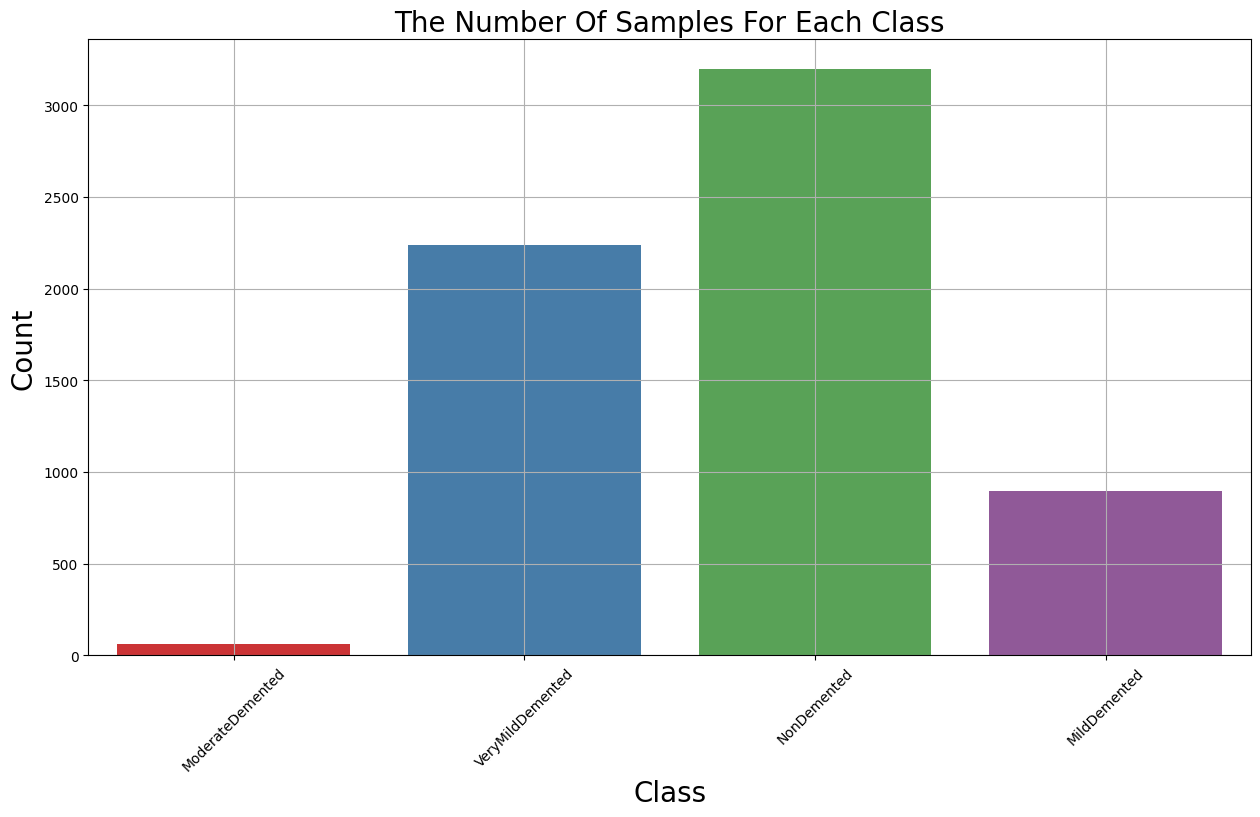

In [6]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x=df.label,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

<ipython-input-7-384bca6a6f0b>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_train = sns.countplot(x=df_train['label'], palette='Set1')


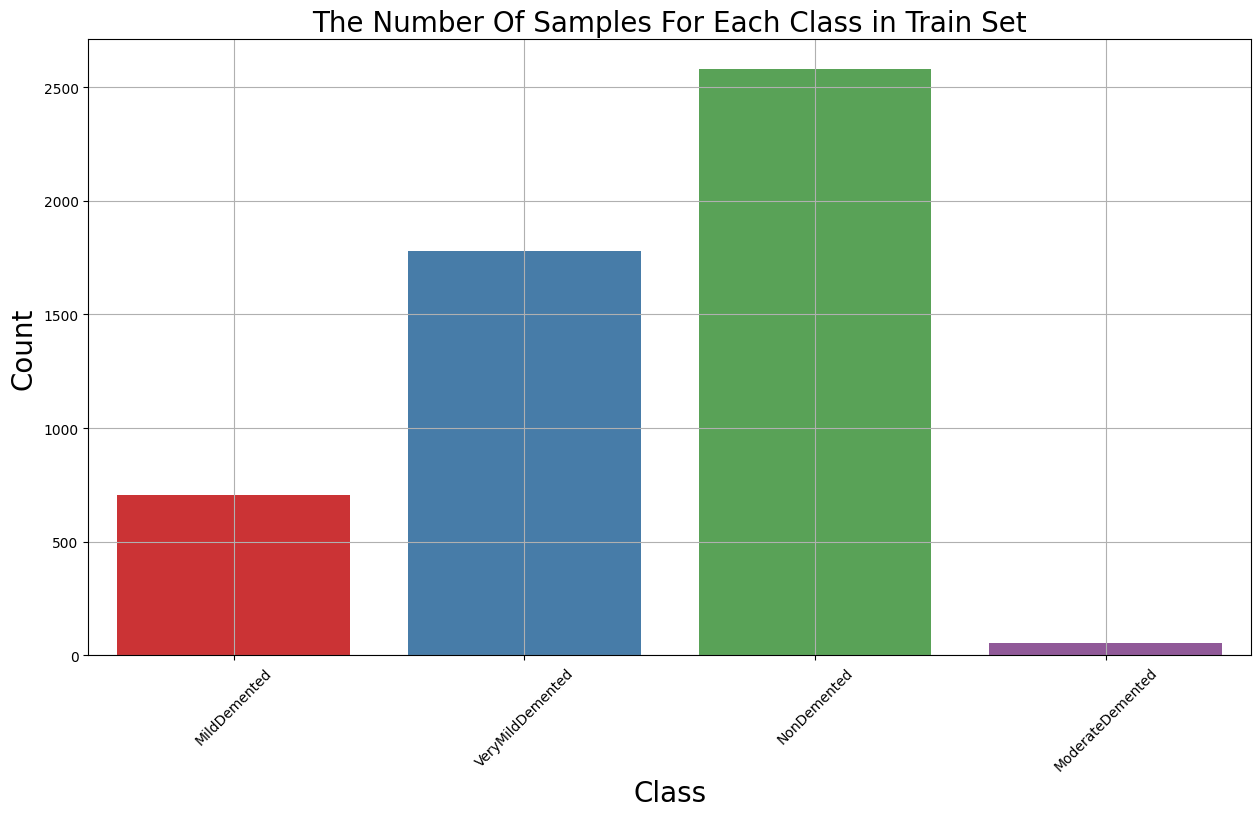

<ipython-input-7-384bca6a6f0b>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_test = sns.countplot(x=df_test['label'], palette='Set1')


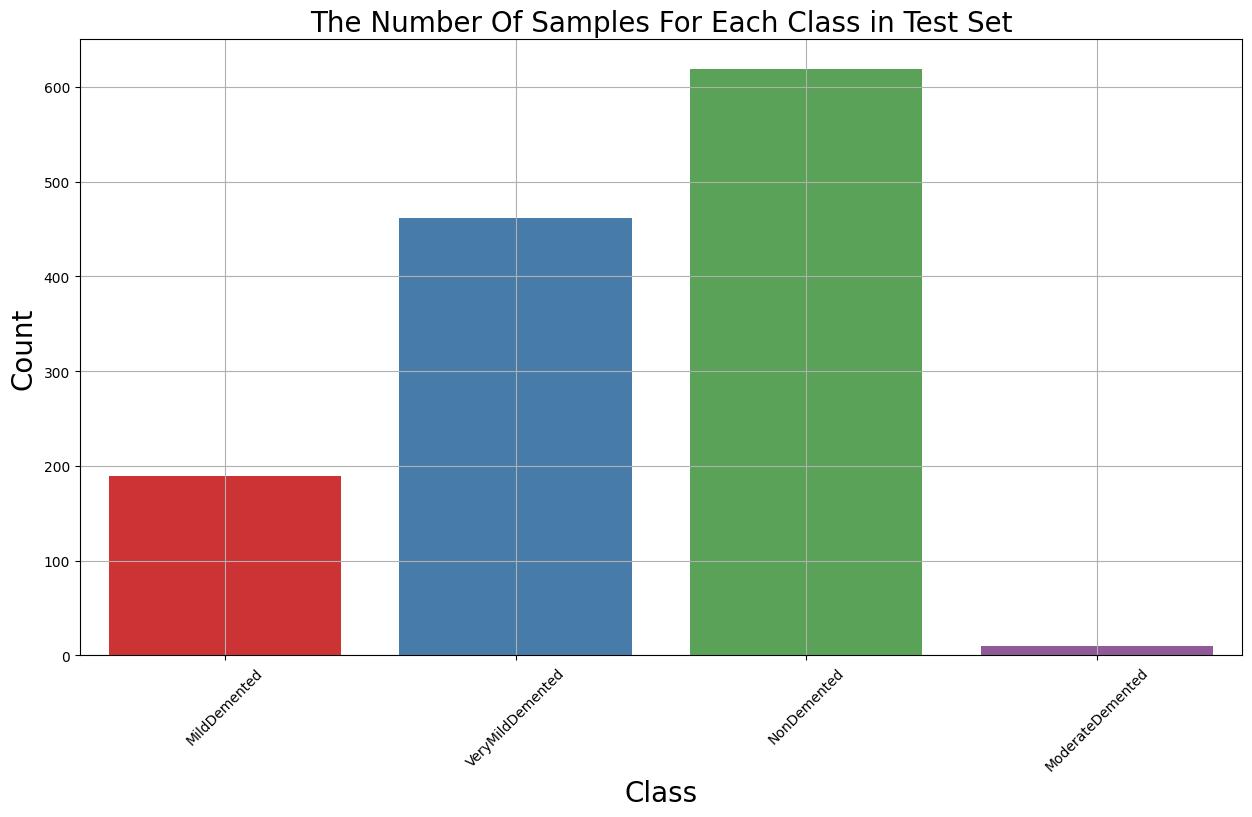

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a DataFrame 'df' with 'label' column containing four classes
# You need to split it into 'train' and 'test' subsets

# Example: Splitting into 'train' and 'test' subsets
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Plot count for 'train' subset
plt.figure(figsize=(15, 8))
ax_train = sns.countplot(x=df_train['label'], palette='Set1')
ax_train.set_xlabel("Class", fontsize=20)
ax_train.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class in Train Set', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Plot count for 'test' subset
plt.figure(figsize=(15, 8))
ax_test = sns.countplot(x=df_test['label'], palette='Set1')
ax_test.set_xlabel("Class", fontsize=20)
ax_test.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class in Test Set', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [8]:
import os
import pandas as pd

images = []
labels = []

for subfolder in os.listdir('/content/drive/MyDrive/Alzheimer Dataset'):
    subfolder_path = os.path.join('/content/drive/MyDrive/Alzheimer Dataset', subfolder)
    for folder in os.listdir(subfolder_path):
        subfolder_path2 = os.path.join(subfolder_path, folder)
        for image_filename in os.listdir(subfolder_path2):
            image_path = os.path.join(subfolder_path2, image_filename)
            images.append(image_path)
            labels.append(folder)

# Create a DataFrame
df = pd.DataFrame({'image': images, 'label': labels})

# Print unique class labels
print(df['label'].unique())


['ModerateDemented' 'VeryMildDemented' 'NonDemented' 'MildDemented']


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming you have a directory structure with 'train' and 'test' subdirectories
train_data_dir = '/content/drive/MyDrive/Alzheimer Dataset/train'
batch_size = 32

# Create an ImageDataGenerator for data augmentation and normalization
train_data_gen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)

# Flow training images in batches using the generator
train_generator = train_data_gen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),  # Adjust this based on your input size
    batch_size=batch_size,
    class_mode='categorical'  # Adjust based on your problem type (binary, categorical, etc.)
)

# Fetch the next batch of training data and labels
train_data, train_labels = train_generator.next()


Found 5121 images belonging to 4 classes.


In [10]:
class_num=np.sort(['MildDemented','ModerateDemented','NonDemented','VeryMildDemented'])
class_num

array(['MildDemented', 'ModerateDemented', 'NonDemented',
       'VeryMildDemented'], dtype='<U16')

<ipython-input-11-671c5a574679>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=labels,palette='Set1')


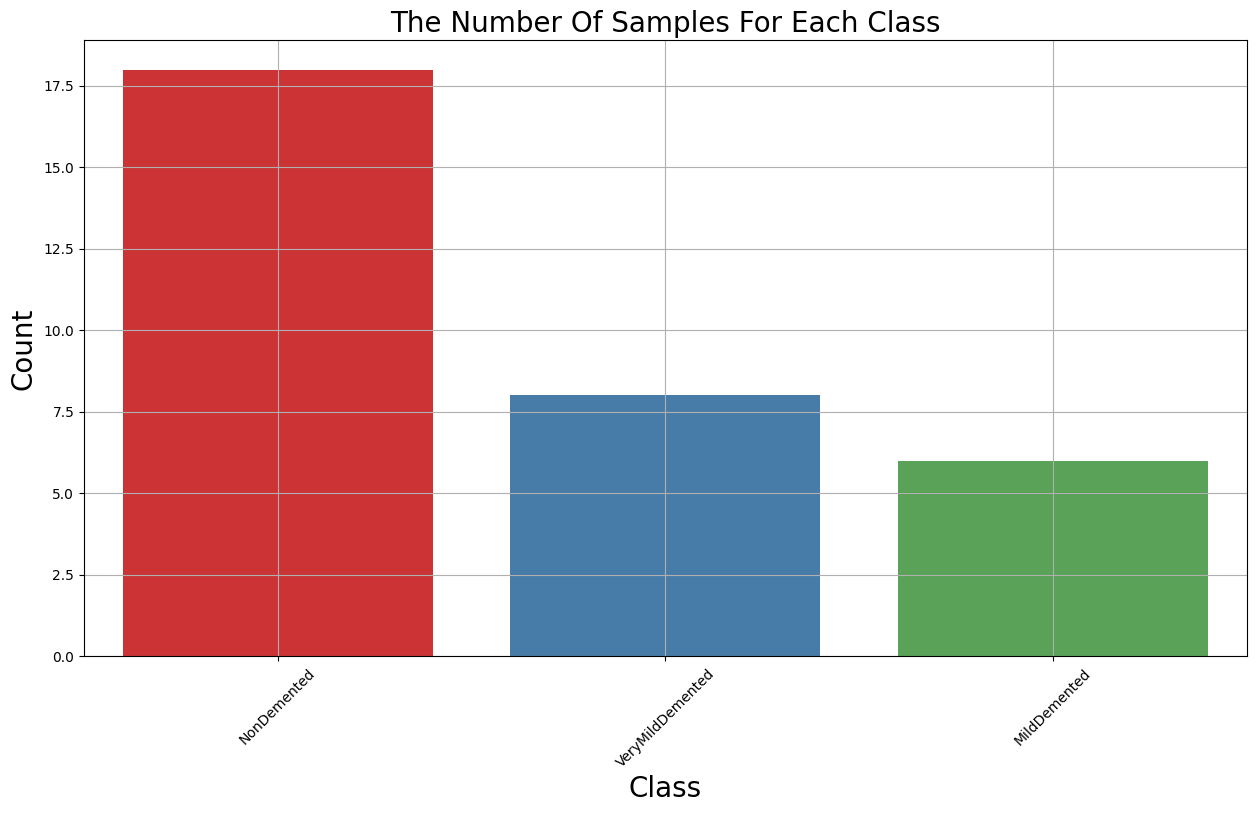

In [11]:
labels=[class_num[i] for i in np.argmax(train_labels,axis=1) ]
plt.figure(figsize=(15,8))
ax = sns.countplot(x=labels,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [12]:
import numpy as np
from sklearn.datasets import make_classification

# Generate a synthetic dataset for illustration
# Replace this with your actual dataset loading code
# Assuming X contains features (MRI scans) and y contains labels (0 for non-Alzheimer's, 1 for Alzheimer's)

# Example: Synthetic dataset
# You should replace this with loading your actual dataset
X, y = make_classification(
    n_samples=1000,
    n_features=176*176*3,  # Adjust based on your image dimensions
    n_informative=50,  # Adjust based on your data characteristics
    n_classes=2,
    random_state=42
)

# Print the shape of the dataset (replace this with your actual dataset shape)
print("Dataset shape:", X.shape, y.shape)


Dataset shape: (1000, 92928) (1000,)


In [13]:
from skimage import transform
from sklearn.preprocessing import StandardScaler

# Assuming X contains features (MRI scans) and y contains labels
# Replace this with your actual dataset loading code

# Example: Resizing and Normalizing
# You should replace this with your actual preprocessing steps

# Reshape each image to a common size (adjust based on your requirements)
target_size = (176, 176)
X_resized = np.array([transform.resize(image.reshape(176, 176, 3), target_size) for image in X])

# Flatten the images (assuming 176x176x3 images)
X_flattened = X_resized.reshape(X_resized.shape[0], -1)

# Normalize pixel values using StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_flattened)

# Print the shape of the preprocessed dataset
print("Preprocessed dataset shape:", X_normalized.shape)


Preprocessed dataset shape: (1000, 92928)


In [14]:
from sklearn.model_selection import train_test_split

# Assuming X_normalized contains preprocessed features and y contains labels
# Replace this with your actual preprocessed data and labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,  # Replace with your actual features
    y,             # Replace with your actual labels
    test_size=0.2,  # Adjust the test_size based on your preference
    random_state=42,
    stratify=y      # Use stratified sampling to maintain class distribution
)

# Print the shapes of the resulting sets
print("Training set shapes:", X_train.shape, y_train.shape)
print("Testing set shapes:", X_test.shape, y_test.shape)


Training set shapes: (800, 92928) (800,)
Testing set shapes: (200, 92928) (200,)


In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Assuming X_train contains training features, y_train contains training labels
# Replace this with your actual training data

# Create a KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=3)  # Adjust the number of neighbors as needed

# Train the KNN model
knn_model.fit(X_train, y_train)

# Optionally, you can also perform hyperparameter tuning or model evaluation here


KNeighborsClassifier(n_neighbors=3)

In [16]:
from sklearn.model_selection import GridSearchCV

# Assuming X_train contains training features, y_train contains training labels
# Replace this with your actual training data

# Create a KNN classifier
knn_model = KNeighborsClassifier()

# Define the hyperparameters to tune
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}  # Adjust the range based on your preference

# Perform grid search with cross-validation
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print the best hyperparameter(s) and corresponding accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Best Hyperparameter(s):", best_params)
print("Best Accuracy:", best_accuracy)


Best Hyperparameter(s): {'n_neighbors': 9}
Best Accuracy: 0.5287499999999999


In [17]:
import joblib

# Assuming knn_model is your trained KNN model
# Replace this with your actual KNN model variable

# Save the model to a file
model_filename = 'knn_alzheimer_model.joblib'
joblib.dump(knn_model, model_filename)

print(f"Model saved as {model_filename}")


Model saved as knn_alzheimer_model.joblib


In [18]:
# Load the model from the saved file
loaded_model = joblib.load(model_filename)

# Now, you can use loaded_model for predictions on new data


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import joblib

# Assuming X_train contains training features and y_train contains training labels
# Replace this with your actual training data

# Create and train a KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Save the model to a file
model_filename = 'knn_alzheimer_model.joblib'
joblib.dump(knn_model, model_filename)

print(f"Model saved as {model_filename}")


Model saved as knn_alzheimer_model.joblib


In [20]:
from PIL import Image

# Open the image file
image_path = '/content/drive/MyDrive/Alzheimer Dataset/train/MildDemented/mildDem0.jpg'  # Replace with the actual path to your image
image = Image.open(image_path)

# Get the size (width and height) of the image
image_size = image.size

# Print the image size
print("Image size (width, height):", image_size)


Image size (width, height): (176, 208)


In [21]:
from PIL import Image
import numpy as np

# Load and preprocess the image from your local path
image_path = '/content/drive/MyDrive/Alzheimer Dataset/train/MildDemented/mildDem0.jpg'
image = Image.open(image_path)
# Assuming you need to resize the image to match the training data dimensions (adjust as needed)
image = image.resize((176, 176))
# Flatten or reshape the image to match the expected input size
image_array = np.array(image).flatten().reshape(1, -1)

# Make a prediction
prediction = loaded_model.predict(image_array)

print("Predicted class:", prediction)


NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [22]:
from PIL import Image
import numpy as np
import joblib

# Load the KNN model
loaded_model = joblib.load('knn_alzheimer_model.joblib')

# File path to the first image in your dataset (replace with your actual path)
first_image_path = '/content/drive/MyDrive/Alzheimer Dataset/train/MildDemented/mildDem0.jpg'

# Load and preprocess the image
image = Image.open(first_image_path)
# Assuming you need to resize the image to match the training data dimensions (adjust as needed)
image = image.resize((176, 176))
image_array = np.array(image)

# Check the shape before reshape
print("Image shape before reshape:", image_array.shape)

# Flatten and reshape the image according to the correct expected input size of your model
expected_input_size = loaded_model.n_features_in_
image_array = image_array.flatten().reshape(1, expected_input_size)

# Check the shape after reshape
print("Image shape after reshape:", image_array.shape)

# Make a prediction
prediction = loaded_model.predict(image_array)

print("Predicted class:", prediction)


Image shape before reshape: (176, 176)


ValueError: cannot reshape array of size 30976 into shape (1,92928)

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Function to generate synthetic images
def generate_image(size=(10, 10)):
    return np.random.randint(0, 256, size)

# Number of synthetic images to generate
num_images = 100

# Generate synthetic images and labels
images = [generate_image() for _ in range(num_images)]
labels = ['pattern' if np.random.rand() < 0.5 else 'no_pattern' for _ in range(num_images)]

# Flatten each image to use pixel values as features
features = [image.flatten() for image in images]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Initialize and train the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_model.predict(X_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.65


In [24]:
import numpy as np
from PIL import Image

# Assuming 'image' is a 2D NumPy array representing the image
# You can load an image using PIL.Image.open('path_to_image') and convert it to a NumPy array

# Example image (replace this with your actual image data)
image = np.array([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])

# Flatten the image
flattened_image = image.flatten()

print("Original Image:")
print(image)
print("\nFlattened Image:")
print(flattened_image)


Original Image:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Flattened Image:
[1 2 3 4 5 6 7 8 9]


In [25]:


from PIL import Image
import numpy as np

# Load the image using PIL
image_path = '/content/drive/MyDrive/Alzheimer Dataset/train/MildDemented/mildDem0.jpg'  # Replace with the actual path to your image
image = Image.open(image_path)

# Resize the image if needed
target_size = (176, 176)  # Replace with the desired size
image = image.resize(target_size)

# Convert the image to a NumPy array
image_array = np.array(image)

# Flatten or reshape the image based on your model's requirements
# For example, if your KNN model expects a flattened array with 30976 features:
# flattened_image = image_array.flatten()

# If your model expects a different shape, adjust accordingly
# For example, if your KNN model expects (1, 30976):
# reshaped_image = image_array.flatten().reshape(1, -1)

# Normalize or scale the pixel values if needed
# For example, scale the pixel values to the range [0, 1]:
# normalized_image = image_array / 255.0

# Now, 'normalized_image' or 'reshaped_image' can be used as input to your KNN model


In [26]:
PROCESSING_MODULE = tf.keras.applications.efficientnet_v2.preprocess_input
train_generator = ImageDataGenerator(
    preprocessing_function=PROCESSING_MODULE,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    preprocessing_function=PROCESSING_MODULE
)

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the target size and batch size
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

# Create an ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)  # You can add more augmentations here if needed

# Create a generator for training images
train_generator = datagen.flow_from_directory(
    directory='/content/drive/MyDrive/Alzheimer Dataset/train/',
    target_size=TARGET_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Create a generator for validation images
val_generator = datagen.flow_from_directory(
    directory='/content/drive/MyDrive/Alzheimer Dataset/test/',
    target_size=TARGET_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Now, you can use train_generator and val_generator in your model training.


Found 5121 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


In [28]:
# Load the pretained model
pretrained_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet',
    pooling='max'
)

pretrained_model.trainable = False

24274472/24274472 [==============================] - 1s 0us/step


In [29]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Create checkpoint callback
checkpoint_path = "mld_classification_model_checkpoint"
checkpoint_callback = ModelCheckpoint(checkpoint_path,
                                      save_weights_only=True,
                                      monitor="val_accuracy",
                                      save_best_only=True)

# Setup EarlyStopping callback to stop training if model's val_loss doesn't improve for 3 epochs
early_stopping = EarlyStopping(monitor="val_loss",  # watch the val loss metric
                               patience=5,
                               restore_best_weights=True)  # if val loss decreases for 3 epochs in a row, stop training

# Setup ReduceLROnPlateau callback to adjust learning rate if val_loss plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)


In [30]:
from keras import backend as K

def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [31]:
import warnings
warnings.filterwarnings("ignore")

In [32]:
PATH = "/content/drive/MyDrive/Alzheimer Dataset/train"

BATCH_SIZE = 32
IMG_SIZE = 224

TRAIN_DS = tf.keras.utils.image_dataset_from_directory(
  PATH,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

VALID_DS = tf.keras.utils.image_dataset_from_directory(
  PATH,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

CLASSES = TRAIN_DS.class_names

count = np.zeros(len(CLASSES), dtype=np.int32)
for _, labels in TRAIN_DS:
    y, _, c = tf.unique_with_counts(labels)
    count[y.numpy()] += c.numpy()
class_weight = dict(enumerate(count))

AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DS = TRAIN_DS.cache().prefetch(buffer_size=AUTOTUNE)
VALID_DS = VALID_DS.cache().prefetch(buffer_size=AUTOTUNE)

Found 5121 files belonging to 4 classes.
Using 4097 files for training.
Found 5121 files belonging to 4 classes.
Using 1024 files for validation.


In [33]:
model = tf.keras.models.Sequential(name="DeepReLUwithEfficientNetB0")
model.add(tf.keras.applications.efficientnet.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(4096, activation='relu'))
model.add(tf.keras.layers.Dense(1024, activation='relu'))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(len(CLASSES), activation='softmax'))
model.layers[0].trainable = False
model.summary()

16705208/16705208 [==============================] - 1s 0us/step
Model: "DeepReLUwithEfficientNetB0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 flatten (Flatten)           (None, 62720)             0         
                                                                 
 dense (Dense)               (None, 4096)              256905216 
                                                                 
 dense_1 (Dense)             (None, 1024)              4195328   
                                                                 
 dense_2 (Dense)             (None, 256)               262400    
                                                                 
 dense_3 (Dense)             (None, 64)  

In [34]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
training_history = model.fit(TRAIN_DS, validation_data=VALID_DS, epochs=30, class_weight=class_weight)
results = pd.DataFrame({
    "Training Accuracy": training_history.history['accuracy'],
    "Validation Accuracy": training_history.history['val_accuracy'],
    "Training Loss": training_history.history['loss'],
    "Validation Loss": training_history.history['val_loss']
})

Epoch 1/30
129/129 [==============================] - 232s 2s/step - loss: 1464.9014 - accuracy: 0.5650 - val_loss: 1.2183 - val_accuracy: 0.5625
Epoch 2/30
129/129 [==============================] - 18s 139ms/step - loss: 1143.8499 - accuracy: 0.6122 - val_loss: 0.8541 - val_accuracy: 0.6289
Epoch 3/30
129/129 [==============================] - 17s 135ms/step - loss: 922.4387 - accuracy: 0.6776 - val_loss: 0.8461 - val_accuracy: 0.6367
Epoch 4/30
129/129 [==============================] - 17s 134ms/step - loss: 819.1947 - accuracy: 0.7069 - val_loss: 0.6498 - val_accuracy: 0.7402
Epoch 5/30
129/129 [==============================] - 17s 134ms/step - loss: 674.9316 - accuracy: 0.7601 - val_loss: 0.7082 - val_accuracy: 0.7246
Epoch 6/30
129/129 [==============================] - 17s 134ms/step - loss: 636.1011 - accuracy: 0.7808 - val_loss: 0.6094 - val_accuracy: 0.7695
Epoch 7/30
129/129 [==============================] - 17s 134ms/step - loss: 505.0221 - accuracy: 0.8262 - val_loss: 0

In [35]:
model.layers[0].trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
training_history = model.fit(TRAIN_DS, validation_data=VALID_DS, epochs=15, class_weight=class_weight)
results_unfrozen = pd.DataFrame({
    "Training Accuracy": training_history.history['accuracy'],
    "Validation Accuracy": training_history.history['val_accuracy'],
    "Training Loss": training_history.history['loss'],
    "Validation Loss": training_history.history['val_loss']
})

Epoch 1/15
129/129 [==============================] - 85s 344ms/step - loss: 1032.5067 - accuracy: 0.6397 - val_loss: 1.0657 - val_accuracy: 0.5371
Epoch 2/15
129/129 [==============================] - 43s 332ms/step - loss: 463.6465 - accuracy: 0.8394 - val_loss: 1.4453 - val_accuracy: 0.5645
Epoch 3/15
129/129 [==============================] - 43s 334ms/step - loss: 189.8827 - accuracy: 0.9331 - val_loss: 1.0187 - val_accuracy: 0.6104
Epoch 4/15
129/129 [==============================] - 43s 333ms/step - loss: 143.9184 - accuracy: 0.9490 - val_loss: 1.3531 - val_accuracy: 0.5605
Epoch 5/15
129/129 [==============================] - 43s 333ms/step - loss: 107.3881 - accuracy: 0.9570 - val_loss: 1.2913 - val_accuracy: 0.6445
Epoch 6/15
129/129 [==============================] - 44s 337ms/step - loss: 81.9929 - accuracy: 0.9670 - val_loss: 0.5693 - val_accuracy: 0.8379
Epoch 7/15
129/129 [==============================] - 43s 334ms/step - loss: 69.4309 - accuracy: 0.9712 - val_loss: 0.

In [36]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
training_history = model.fit(TRAIN_DS, validation_data=VALID_DS, epochs=15, class_weight=class_weight)
results_unfrozen_low_lr = pd.DataFrame({
    "Training Accuracy": training_history.history['accuracy'],
    "Validation Accuracy": training_history.history['val_accuracy'],
    "Training Loss": training_history.history['loss'],
    "Validation Loss": training_history.history['val_loss']
})

Epoch 1/15
129/129 [==============================] - 81s 347ms/step - loss: 8.6725 - accuracy: 0.9973 - val_loss: 0.1399 - val_accuracy: 0.9717
Epoch 2/15
129/129 [==============================] - 43s 337ms/step - loss: 4.4619 - accuracy: 0.9985 - val_loss: 0.1286 - val_accuracy: 0.9775
Epoch 3/15
129/129 [==============================] - 43s 335ms/step - loss: 3.4002 - accuracy: 0.9993 - val_loss: 0.1539 - val_accuracy: 0.9795
Epoch 4/15
129/129 [==============================] - 43s 335ms/step - loss: 3.6517 - accuracy: 0.9985 - val_loss: 0.1496 - val_accuracy: 0.9795
Epoch 5/15
129/129 [==============================] - 43s 333ms/step - loss: 5.3292 - accuracy: 0.9985 - val_loss: 0.1598 - val_accuracy: 0.9707
Epoch 6/15
129/129 [==============================] - 43s 335ms/step - loss: 1.8247 - accuracy: 0.9990 - val_loss: 0.1329 - val_accuracy: 0.9795
Epoch 7/15
129/129 [==============================] - 44s 340ms/step - loss: 5.6633 - accuracy: 0.9990 - val_loss: 0.1402 - val_ac

In [ ]:
training_history = model.fit(TRAIN_DS, validation_data=VALID_DS, epochs=30, class_weight=class_weight,
                             callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights= True, baseline=0.99)])

results_unfrozen_low_lr_final = pd.DataFrame({
    "Training Accuracy": training_history.history['accuracy'],
    "Validation Accuracy": training_history.history['val_accuracy'],
    "Training Loss": training_history.history['loss'],
    "Validation Loss": training_history.history['val_loss']
})

Epoch 1/30
129/129 [==============================] - ETA: 0s - loss: 5.5766 - accuracy: 0.9985